In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("Tweets.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
df = df[["text", "airline_sentiment"]]

In [4]:
df.dropna(inplace=True)

In [5]:
le = LabelEncoder()

y = le.fit_transform(df["airline_sentiment"])

In [6]:
X = df["text"]

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)

In [7]:
X_pad = pad_sequences(
    X_seq,
    maxlen=50
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
model = Sequential([
    Embedding(input_dim=5000,
              output_dim=32,
              input_length=50),

    LSTM(32),

    Dense(3, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32
)

Epoch 1/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.6987 - loss: 0.7194 - val_accuracy: 0.7772 - val_loss: 0.5854
Epoch 2/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8194 - loss: 0.4632 - val_accuracy: 0.8092 - val_loss: 0.4992
Epoch 3/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8675 - loss: 0.3445 - val_accuracy: 0.8024 - val_loss: 0.5400
Epoch 4/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8992 - loss: 0.2746 - val_accuracy: 0.7956 - val_loss: 0.5934
Epoch 5/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9178 - loss: 0.2226 - val_accuracy: 0.7887 - val_loss: 0.6163


In [13]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7934 - loss: 0.6218
Test Accuracy: 0.7933743000030518


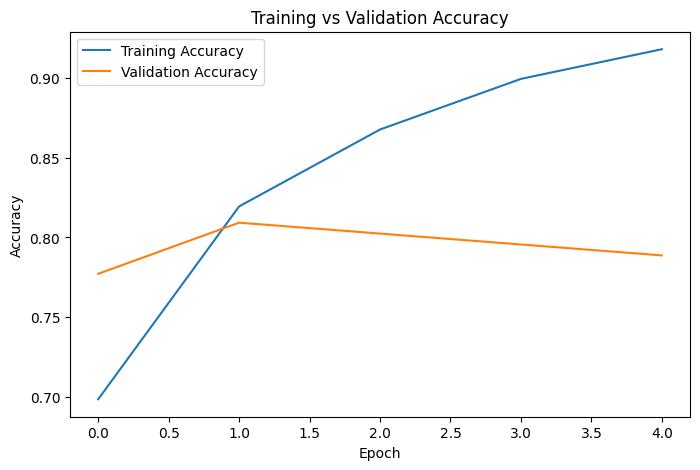

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

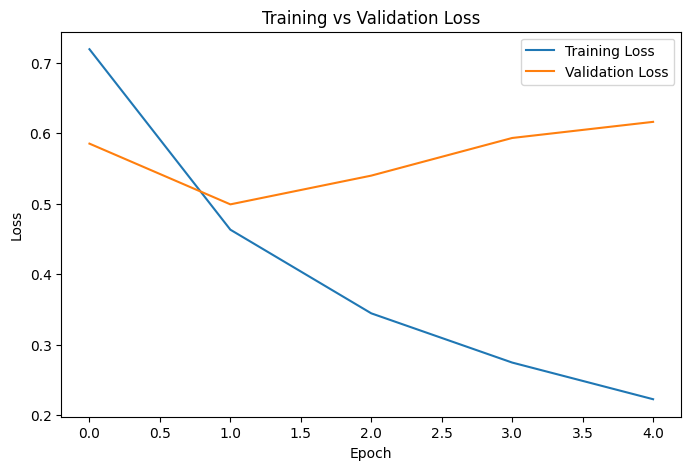

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [16]:
from tensorflow.keras.layers import GRU

model = Sequential([
    Embedding(5000, 32, input_length=50),
    GRU(32),
    Dense(3, activation="softmax")
])